# Virtual heart, experiment 2: a tissue sheet

### 2a. Cardiac activation wave in a disc-shaped domain (simplified atrium / in vitro culture)

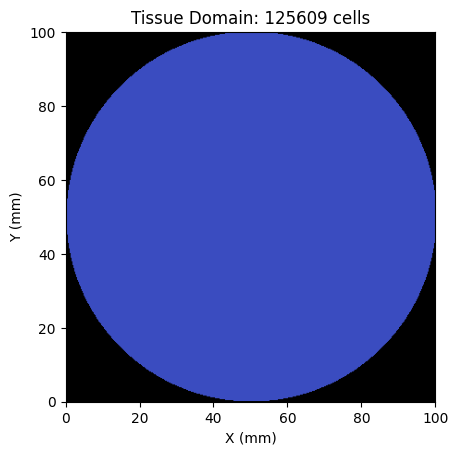

number of used grid points: 125609
total number of grid points: 160000


In [28]:
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 400 # 100 (mm)
DR = 0.25 # (mm)

x, y = np.meshgrid(np.arange(GRID_SIZE), np.arange(GRID_SIZE))
X, Y = x.flatten(), y.flatten()
R = np.sqrt((X - GRID_SIZE / 2) ** 2 + (Y - GRID_SIZE / 2) ** 2) 
R = R.reshape((GRID_SIZE, GRID_SIZE))
mesh = (np.abs(R) < GRID_SIZE/2).astype(int)

domain = mesh.astype(float)
domain[domain == 0] = np.nan
cmap = plt.get_cmap("coolwarm")
cmap.set_bad(color="black")

plt.figure()
plt.title(f"Tissue Domain: {np.count_nonzero(mesh)} cells")
plt.imshow(domain, cmap=cmap, extent=[0, 100, 0, 100], origin="lower")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.show()

print('number of used grid points:', np.sum(mesh))
print('total number of grid points:', GRID_SIZE*GRID_SIZE)

In [43]:
from pathlib import Path
import numpy as np
from finitewave_tools.animation import Frame2DRenderer, AnimationBuilder


def write_animation(animation_name, frames, mask, nan_mask=None):
    output_dir = Path("./output")

    frame_renderer = Frame2DRenderer()
    frame_renderer.set_frames(frames=frames)
    frame_renderer.configure_grid(np.ones((GRID_SIZE, GRID_SIZE)))

    animation = AnimationBuilder()
    animation.frame_renderer = frame_renderer
    animation.write(
        path=output_dir,
        animation_name=animation_name,
        fps=24,
        prog_bar=True,
        clim=(0, 1),
        cmap="plasma",
        output_mask=mask,
        nan_mask=nan_mask
    )

    video_path = output_dir / f"{animation_name}.mp4"
    return video_path

In [ ]:
from IPython.display import Video, display
import finitewave as fw


T_MAX = 1000
EXP_NAME = "sinus_on_plate"
# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([GRID_SIZE, GRID_SIZE], dr=DR)
tissue.mesh = mesh.copy()

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
for t_stim in np.arange(0, T_MAX, 400):
    stim_sequence.add_stim(fw.StimCurrentCoord(time=t_stim,
                                               curr_value=100,
                                               duration=1,
                                               x_min=0, x_max=5,
                                               y_min=0, y_max=GRID_SIZE))

# create trackers
frame_tracker = fw.FrameTracker(step=300, aggregate=True)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=T_MAX, backend="jax")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.MitchellSchaeffer()
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

frames = frame_tracker.frames[:len(frame_tracker.tracking_times)]

video_path = write_animation(EXP_NAME, frames, mask=(mesh==1))

display(Video(str(video_path), embed=True, width=600))

Running MitchellSchaeffer on (400, 400) Grid:   0%|          | 0/100000 [00:00<?, ?it/s]

Building animation: 100%|██████████| 334/334 [00:00<00:00, 353.51it/s]


## 2b: add a second pulse with position and timing to cause arrhythmia (e.g. impact to the chest)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw


def build_s1s2_protocol(shape, t_max, basic_cycle_length, s2_time):
    """Build a stimulation protocol to induce reentry in a tissue.
    The protocol consists of a series of S1 stimuli followed by a single S2 stimulus."""
    stim_sequence = fw.StimSequence()
    for t_stim in range(0, t_max, basic_cycle_length):
        stim_sequence.add_stim(fw.StimCurrentCoord(time=t_stim,
                                                   curr_value=100,
                                                   duration=2,
                                                   x_min=1, x_max=5,
                                                   y_min=1, y_max=shape[1]))

    stim_sequence.add_stim(fw.StimCurrentCoord(time=s2_time,
                                               curr_value=100,
                                               duration=2,
                                               x_min=0, x_max=shape[0]//2,
                                               y_min=0 , y_max=shape[1]//2 ))
    return stim_sequence


T_MAX = 1500
EXP_NAME = "spiral_on_plate"

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, T_MAX, basic_cycle_length=600, s2_time=350)

# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([GRID_SIZE, GRID_SIZE], dr=DR)
tissue.mesh = mesh.copy()

# create trackers
frame_tracker = fw.FrameTracker(step=300, aggregate=True)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=T_MAX, backend="jax")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.MitchellSchaeffer()
simulation.stim_sequence = s1_s2_protocol
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

frames = frame_tracker.frames[:len(frame_tracker.tracking_times)]

video_path = write_animation(EXP_NAME, frames, mask=(mesh==1))

display(Video(str(video_path), embed=True, width=600))

Running MitchellSchaeffer on (400, 400) Grid:   0%|          | 0/150000 [00:00<?, ?it/s]

Building animation: 100%|██████████| 501/501 [00:01<00:00, 292.19it/s]


# Virtual experiment 3: test therapies in silico? 

## option 3A ablation: create a scar in part of the tissue 

### 3A1: ablate without a tachycardia present: will it prevent the next one under the same S1-S2 protocol? 

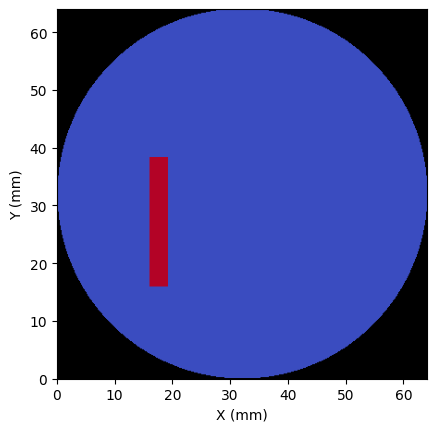

In [38]:
# Let's make part of the tissue unexcitable, to simulate an ablation

tissue_ablated = fw.CardiacTissue([GRID_SIZE, GRID_SIZE], dr=DR)
tissue_ablated.mesh = mesh.copy()
tissue_ablated.mesh[100:120, 100:240] = 2 

domain = tissue_ablated.mesh.astype(float)
domain[domain == 0] = np.nan
cmap = plt.get_cmap("coolwarm")
cmap.set_bad(color="black")

plt.figure()
plt.imshow(domain.T, cmap=cmap, origin="lower", extent=[0, 64, 0, 64])
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.show()


In [ ]:
T_MAX = 1500
EXP_NAME = "ablation_on_plate"

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, T_MAX, basic_cycle_length=600, s2_time=350)

# create trackers
frame_tracker = fw.FrameTracker(step=300, aggregate=True)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=T_MAX, backend="jax")
simulation.cardiac_tissue = tissue_ablated
simulation.cardiac_model = fw.MitchellSchaeffer()
# add the tissue and the stim parameters to the model object:
simulation.stim_sequence = s1_s2_protocol
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

frames = frame_tracker.frames[:len(frame_tracker.tracking_times)]

mesh = tissue_ablated.mesh
fibro_mask = (mesh[mesh > 0] == 2)

video_path = write_animation(EXP_NAME, frames, mask=(mesh>0), nan_mask=fibro_mask)

display(Video(str(video_path), embed=True, width=600))

Building animation: 100%|██████████| 501/501 [00:01<00:00, 320.63it/s]


## option 3A2: do ablation while the arrhythmia is present, but only a small scar connecting the spiral core to boundary.





In [ ]:


class Ablation(fw.Command):
    """Class to represent an ablation command that makes a rectangular region
    of the tissue unexcitable at a specific time."""
    def __init__(self, time, x1, x2, y1, y2):
        super().__init__(time)
        self.x1 = x1
        self.x2 = x2
        self.y1 = y1
        self.y2 = y2

    def execute(self, model):
        model.cardiac_tissue.mesh[self.x1:self.x2, self.y1:self.y2] = 2
        model.compute_weights()


t_max = 1300
command_sequence = fw.CommandSequence()
command_sequence.add_command(Ablation(800, n//4-5, n//4+5, n//2, n))
        
# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([n, n])
tissue.mesh = mesh.copy()
tissue.add_boundaries()

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, t_max, basic_cycle_length=600, s2_time=350)

# create trackers
frame_tracker = FrameTracker(step=1000)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
mitchell_schaeffer_ablation = fw.MitchellSchaeffer()
mitchell_schaeffer_ablation.dt = 0.01
mitchell_schaeffer_ablation.dr = 0.25
mitchell_schaeffer_ablation.t_max = t_max

# add the tissue and the stim parameters to the model object:
mitchell_schaeffer_ablation.cardiac_tissue = tissue
mitchell_schaeffer_ablation.stim_sequence = s1_s2_protocol
mitchell_schaeffer_ablation.tracker_sequence = tracker_sequence
mitchell_schaeffer_ablation.command_sequence = command_sequence

# run the model:
mitchell_schaeffer_ablation.run()

ani = frame_tracker.animate_frames(title="S1-S2 Protocol with Ablation")
HTML(ani.to_jshtml())

## option 3B: drug prescription

In [ ]:
class DrugEffect(fw.Command):
    """ Class to represent a drug effect command that modifies the tau_close
    parameter of the Mitchell-Schaeffer model at a specific time.

    E.g., I_Kr decrease yields slower repolarization,
    which corresponds to a longer time constant tau in the MS model:
    """
    def __init__(self, time, tau_factor):
        super().__init__(time)
        self.tau_factor = tau_factor

    def execute(self, model):
        model.tau_close *= self.tau_factor


t_max = 2000
t_drug = 800
# set up a command sequence to apply the drug effect at a specific time
command_sequence = fw.CommandSequence()
command_sequence.add_command(DrugEffect(t_drug, tau_factor=1.2))

# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([n, n])
tissue.mesh = mesh.copy()
tissue.add_boundaries()

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, t_max, basic_cycle_length=600, s2_time=350)

# create trackers
frame_tracker = FrameTracker(step=2000)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
mitchell_schaeffer_drug = fw.MitchellSchaeffer()
mitchell_schaeffer_drug.dt = 0.01
mitchell_schaeffer_drug.dr = 0.25
mitchell_schaeffer_drug.t_max = t_max

# add the tissue and the stim parameters to the model object:
mitchell_schaeffer_drug.cardiac_tissue = tissue
mitchell_schaeffer_drug.stim_sequence = s1_s2_protocol
mitchell_schaeffer_drug.tracker_sequence = tracker_sequence
mitchell_schaeffer_drug.command_sequence = command_sequence

# run the model:
mitchell_schaeffer_drug.run()

ani = frame_tracker.animate_frames(title="Pharmacological Intervention")
HTML(ani.to_jshtml())

### option 3C: defibrillation

In [1]:
t_max = 1300
t_defib = 1000
# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([n, n])
tissue.mesh = mesh.copy()
tissue.add_boundaries()

stim_sequence = build_s1s2_protocol(mesh.shape, t_max, basic_cycle_length=600, s2_time=350)
# add a depolarizing current to the entire tissue at t=1000:
stim_sequence.add_stim(fw.StimVoltageCoord(time=t_defib,
                                           volt_value=1,
                                           x1=0, x2=n,
                                           y1=0, y2=n ))

# create trackers
frame_tracker = FrameTracker(step=1000)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
mitchell_schaeffer = fw.MitchellSchaeffer()
mitchell_schaeffer.dt = 0.01
mitchell_schaeffer.dr = 0.25
mitchell_schaeffer.t_max = t_max

# add the tissue and the stim parameters to the model object:
mitchell_schaeffer.cardiac_tissue = tissue
mitchell_schaeffer.stim_sequence = stim_sequence
mitchell_schaeffer.tracker_sequence = tracker_sequence

# run the model:
mitchell_schaeffer.run()

ani = frame_tracker.animate_frames(title="Defibrillation")
HTML(ani.to_jshtml())

NameError: name 'fw' is not defined

These simulations were run in open-source cardiac electrophysiology software: FiniteWave:

# Finitewave: a lightweight framework for cardiac electrophysiology simulations

GitHub: https://github.com/finitewave/Finitewave/tree/main
## Cardiac Models
## Typical use cases

1. Planar wave simulations.
2. Spiral wave dynamics.
3. High-pacing protocols.
4. Fibrosis-induced propagation effects.
5. Educational demonstrations of cardiac models or reaction-diffusion systems.
<div style="display: flex; gap: 10px;">
  <img src="https://raw.githubusercontent.com/finitewave/Finitewave/mlx/images/spiral_wave_fib.gif" width="19%">
  <img src="https://raw.githubusercontent.com/finitewave/Finitewave/mlx/images/spiral_wave_slab.gif" width="26%">
  <img src="https://raw.githubusercontent.com/finitewave/Finitewave/mlx/images/spiral_wave_lv.gif" width="20%">
  <img src="https://raw.githubusercontent.com/finitewave/Finitewave/mlx/images/atrium.gif" width="20%">
</div>